In [55]:
import pandas as pd

In [56]:
df = pd.read_csv(r"c:\Users\supri\OneDrive\Desktop\RISK-SCORE-PREDICTOR\data\orders.csv")

In [57]:
df.head()

,order_id,order_date,order_value,category,payment_method,customer_age_days,past_orders,past_return_rate,address_mismatch,delivery_days,orders_last_24h,discount_pct,returned
0,R02316,2025-01-01,2634,Electronics,COD,790,10,0.212,0,1,1,20,0
1,R04627,2025-01-01,1732,Books,Prepaid,122,5,0.253,0,12,1,70,0
2,R01237,2025-01-01,667,Electronics,Prepaid,323,3,0.119,0,2,1,0,0
3,R00846,2025-01-01,953,Electronics,Prepaid,874,13,0.230,0,9,3,10,0
4,R04691,2025-01-01,515,Clothing,COD,620,9,0.339,0,12,1,5,1


NUMBER OF ROWS AND COLUMNS-


In [58]:
df.shape

(6000, 13)

RETURN RATE

In [59]:
print("\nReturn rate:")
print(df["returned"].value_counts(normalize=True))


Return rate:
returned
0    0.853167
1    0.146833
Name: proportion, dtype: float64


TIME-BASED SPLIT

In [60]:
df['order_date']=pd.to_datetime(df["order_date"])
df=df.sort_values(by="order_date").reset_index(drop=True)

In [61]:
split_index=int(len(df)*0.8)

TRAINING MODEL

In [62]:
train=df.iloc[:split_index]
test=df.iloc[split_index:]

In [63]:
print("Train rows:", len(train), "| dates:", train["order_date"].min().date(), "->", train["order_date"].max().date())
print("Test rows: ", len(test),  "| dates:", test["order_date"].min().date(),  "->", test["order_date"].max().date())

Train rows: 4800 | dates: 2025-01-01 -> 2025-05-25
Test rows:  1200 | dates: 2025-05-25 -> 2025-06-30


In [64]:
df[["order_id", "order_date"]].head()

,order_id,order_date
0,R02316,2025-01-01
1,R04598,2025-01-01
2,R02442,2025-01-01
3,R00845,2025-01-01
4,R04111,2025-01-01


CHOOSING FEATURES- X, TARGET- Y

In [65]:
target = "returned"

drop_cols = ["returned", "order_id", "order_date"]

feature_cols = [c for c in df.columns if c not in drop_cols]

print("Target:", target)
print("\nFeatures the model will use:")
for c in feature_cols:
    print(" -", c)

Target: returned

Features the model will use:
 - order_value
 - category
 - payment_method
 - customer_age_days
 - past_orders
 - past_return_rate
 - address_mismatch
 - delivery_days
 - orders_last_24h
 - discount_pct


payment_method          payment_method_Prepaid
--------------          ----------------------
COD              →       0
Prepaid          →       1
COD              →       0

In [66]:
X_train = train[feature_cols]
y_train = train[target]

X_test = test[feature_cols]
y_test = test[target]

X_train = pd.get_dummies(X_train, columns=["category", "payment_method"])
X_test  = pd.get_dummies(X_test,  columns=["category", "payment_method"])

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
X_train.head()

X_train shape: (4800, 15)
X_test shape:  (1200, 15)


,order_value,customer_age_days,past_orders,past_return_rate,address_mismatch,delivery_days,orders_last_24h,discount_pct,category_Beauty,category_Books,category_Clothing,category_Electronics,category_Home,payment_method_COD,payment_method_Prepaid
0,2634,790,10,0.212,0,1,1,20,False,False,False,True,False,True,False
1,189,359,9,0.127,1,8,4,10,False,False,False,False,True,False,True
2,347,69,3,0.121,0,3,1,0,True,False,False,False,False,True,False
3,2031,248,6,0.159,0,5,1,20,False,True,False,False,False,True,False
4,413,70,3,0.027,0,11,1,10,False,True,False,False,False,True,False


LOGISTIC REGRESSION

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


logreg = LogisticRegression(class_weight="balanced", max_iter=1000)
logreg.fit(X_train_scaled, y_train)

print("Model trained (scaled).")

Model trained (scaled).


In [68]:
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, confusion_matrix

y_scores = logreg.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_scores >= 0.5).astype(int)

print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:   ", round(recall_score(y_test, y_pred), 3))
print("F1 score: ", round(f1_score(y_test, y_pred), 3))
print("PR-AUC:   ", round(average_precision_score(y_test, y_scores), 3))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Precision: 0.243
Recall:    0.588
F1 score:  0.344
PR-AUC:    0.326

Confusion matrix:
[[699 324]
 [ 73 104]]


In [69]:
print(logreg.predict_proba(X_test_scaled)[:3])

[[0.48771707 0.51228293]
 [0.55705787 0.44294213]
 [0.65752659 0.34247341]]


RANDOM FOREST CLASSIFIER

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,        
    class_weight="balanced", 
    random_state=42          
)
rf.fit(X_train, y_train)


rf_scores = rf.predict_proba(X_test)[:, 1]
rf_pred = (rf_scores >= 0.5).astype(int)

print("Random Forest results:")
print("Precision:", round(precision_score(y_test, rf_pred), 3))
print("Recall:   ", round(recall_score(y_test, rf_pred), 3))
print("F1 score: ", round(f1_score(y_test, rf_pred), 3))
print("PR-AUC:   ", round(average_precision_score(y_test, rf_scores), 3))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest results:
Precision: 0.333
Recall:    0.028
F1 score:  0.052
PR-AUC:    0.259

Confusion matrix:
[[1013   10]
 [ 172    5]]


XG BOOST

In [71]:
import xgboost
print("xgboost version:", xgboost.__version__)

xgboost version: 3.2.0


In [72]:
from xgboost import XGBClassifier

neg = (y_train == 0).sum()   
pos = (y_train == 1).sum()   
ratio = neg / pos
print("scale_pos_weight ratio:", round(ratio, 2))


xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=ratio,   
    random_state=42,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)


xgb_scores = xgb.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_scores >= 0.5).astype(int)

print("\nXGBoost results:")
print("Precision:", round(precision_score(y_test, xgb_pred), 3))
print("Recall:   ", round(recall_score(y_test, xgb_pred), 3))
print("F1 score: ", round(f1_score(y_test, xgb_pred), 3))
print("PR-AUC:   ", round(average_precision_score(y_test, xgb_scores), 3))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, xgb_pred))

scale_pos_weight ratio: 5.82

XGBoost results:
Precision: 0.262
Recall:    0.373
F1 score:  0.308
PR-AUC:    0.25

Confusion matrix:
[[837 186]
 [111  66]]


## Model Comparison (test set, 0.5 threshold)

| Model | PR-AUC | Recall | Precision | F1 |
|---|---|---|---|---|
| **Logistic Regression** ✅ | **0.326** | 0.588 | 0.243 | 0.344 |
| Random Forest | 0.259 | 0.028 | 0.333 | 0.052 |
| XGBoost | 0.250 | 0.373 | 0.262 | 0.308 |

**Winner: Logistic Regression** — highest PR-AUC (the metric that judges across all thresholds). The simplest model ranked risky orders best, and it's also the most explainable — an advantage for a merchant-facing risk tool.

In [73]:
import numpy as np

COST_FP = 200   
COST_FN = 800   

scores = logreg.predict_proba(X_test_scaled)[:, 1]


thresholds = np.arange(0.0, 1.01, 0.01)  
costs = []

for t in thresholds:
    pred = (scores >= t).astype(int)          
    fp = ((pred == 1) & (y_test == 0)).sum()  
    fn = ((pred == 0) & (y_test == 1)).sum()  
    total_cost = fp * COST_FP + fn * COST_FN
    costs.append(total_cost)

costs = np.array(costs)

best_i = costs.argmin()
best_threshold = thresholds[best_i]
best_cost = costs[best_i]

print("Best threshold:", round(best_threshold, 2))
print("Lowest total cost: ₹", int(best_cost))
print("Cost at default 0.5:", "₹", int(costs[np.argmin(np.abs(thresholds - 0.5))]))

Best threshold: 0.57
Lowest total cost: ₹ 117200
Cost at default 0.5: ₹ 123200


COST_FP = 200
COST_FN = 1500

In [74]:
import numpy as np

COST_FP = 200   
COST_FN = 1500   

scores = logreg.predict_proba(X_test_scaled)[:, 1]

thresholds = np.arange(0.0, 1.01, 0.01)   
costs = []

for t in thresholds:
    pred = (scores >= t).astype(int)          
    fp = ((pred == 1) & (y_test == 0)).sum() 
    fn = ((pred == 0) & (y_test == 1)).sum()  
    total_cost = fp * COST_FP + fn * COST_FN
    costs.append(total_cost)

costs = np.array(costs)


best_i = costs.argmin()
best_threshold = thresholds[best_i]
best_cost = costs[best_i]

print("Best threshold:", round(best_threshold, 2))
print("Lowest total cost: ₹", int(best_cost))
print("Cost at default 0.5:", "₹", int(costs[np.argmin(np.abs(thresholds - 0.5))]))

Best threshold: 0.37
Lowest total cost: ₹ 160900
Cost at default 0.5: ₹ 174300


The optimal threshold isn't fixed — it moves with the business. When missed returns cost more, my model flags more aggressively and the cutoff drops to 0.37, saving ₹13,400. That's the cost model doing its job."

As the loss of a return fraud and loss of a good customer due to FN AND FP , DEPEND solely on the type of product, we have used this idea-
 The idea: instead of flat prices, each blocked order costs 30% of its value and each missed return costs 120% of its value. The costs now "switch" per order automatically.


In [75]:
order_values = X_test["order_value"].values  

FP_RATE = 0.30
FN_RATE = 1.20

costs = []
for t in thresholds:
    pred = (scores >= t).astype(int)
    fp_mask = (pred == 1) & (y_test.values == 0)  
    fn_mask = (pred == 0) & (y_test.values == 1)   
    cost = (order_values[fp_mask] * FP_RATE).sum() + (order_values[fn_mask] * FN_RATE).sum()
    costs.append(cost)
costs = np.array(costs)

best_i = costs.argmin()
print("Best threshold:", round(thresholds[best_i], 2))
print("Lowest cost: ₹", int(costs[best_i]))
print("Cost at 0.5: ₹", int(costs[np.argmin(np.abs(thresholds - 0.5))]))

Best threshold: 0.57
Lowest cost: ₹ 288684
Cost at 0.5: ₹ 308634


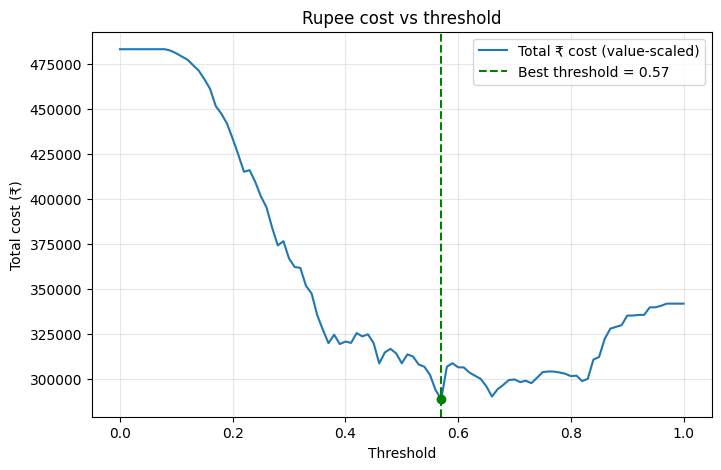

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(thresholds, costs, label="Total ₹ cost (value-scaled)")
plt.axvline(thresholds[best_i], color="green", linestyle="--",
            label=f"Best threshold = {thresholds[best_i]:.2f}")
plt.scatter([thresholds[best_i]], [costs[best_i]], color="green", zorder=5)
plt.title("Rupee cost vs threshold")
plt.xlabel("Threshold")
plt.ylabel("Total cost (₹)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Cost Model Comparison (test set, Logistic Regression)

| Cost model | FP price | FN price | Best threshold | Saving vs 0.5 |
|---|---|---|---|---|
| Flat (moderate) | ₹200 | ₹800 | 0.57 | ₹6,000 |
| Flat (realistic) | ₹200 | ₹1,500 | 0.37 | ₹13,400 |
| **Value-scaled** ✅ | 30% of order value | 120% of order value | 0.57 | **₹19,950** |

**Headline:** with value-aware costs, choosing the threshold by rupee cost saves ~₹20,000 on the test set versus the naive 0.5 default. The exact costs are business assumptions — the pipeline accepts whatever real numbers a platform like Razorpay would calibrate from historical refund and shipping data.

In [77]:
import joblib


joblib.dump(logreg, "../app/model.pkl")
joblib.dump(scaler, "../app/scaler.pkl")
joblib.dump(list(X_train.columns), "../app/feature_columns.pkl")


joblib.dump(float(thresholds[best_i]), "../app/best_threshold.pkl")

print("Saved: model, scaler, feature columns, and best threshold to the app/ folder.")

Saved: model, scaler, feature columns, and best threshold to the app/ folder.


In [78]:
import json

slider_data = {
    "scores": logreg.predict_proba(X_test_scaled)[:, 1].tolist(),
    "labels": y_test.tolist(),
    "order_values": X_test["order_value"].tolist()
}

with open("../app/slider_data.json", "w") as f:
    json.dump(slider_data, f)

print("Saved slider_data.json — ready for the app.")

Saved slider_data.json — ready for the app.
